GEBCO depth at Sines site: -170.00 m (negative = below MSL)


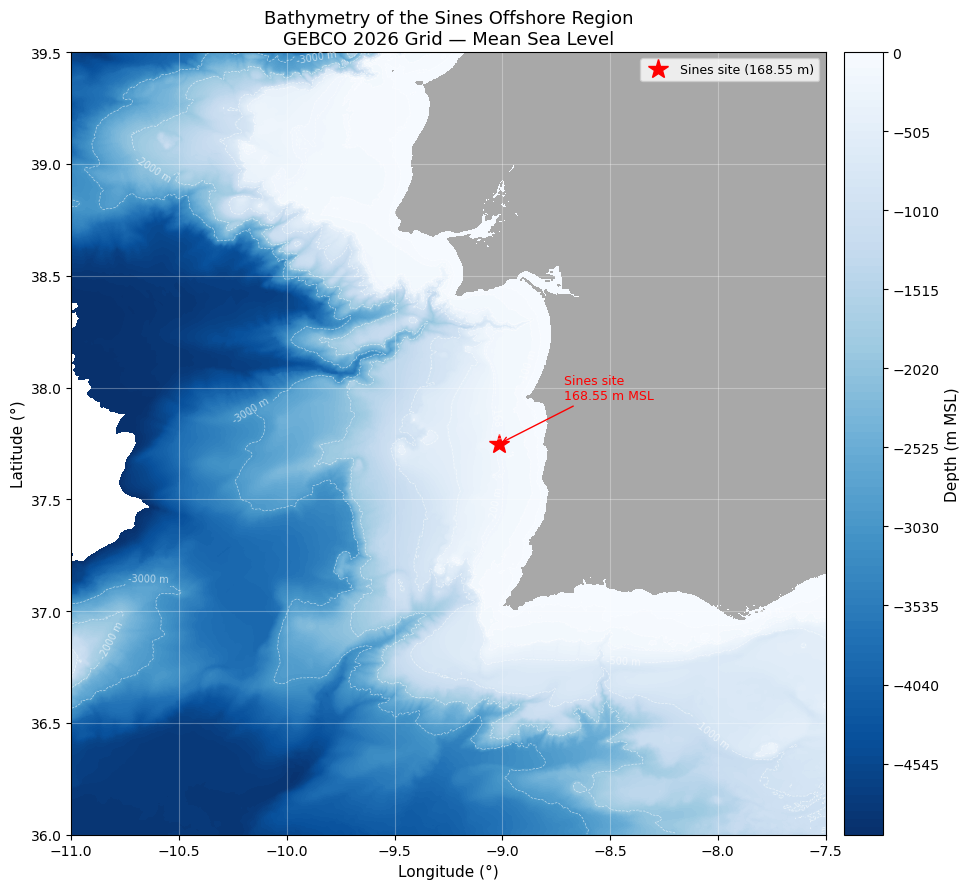

Map saved!


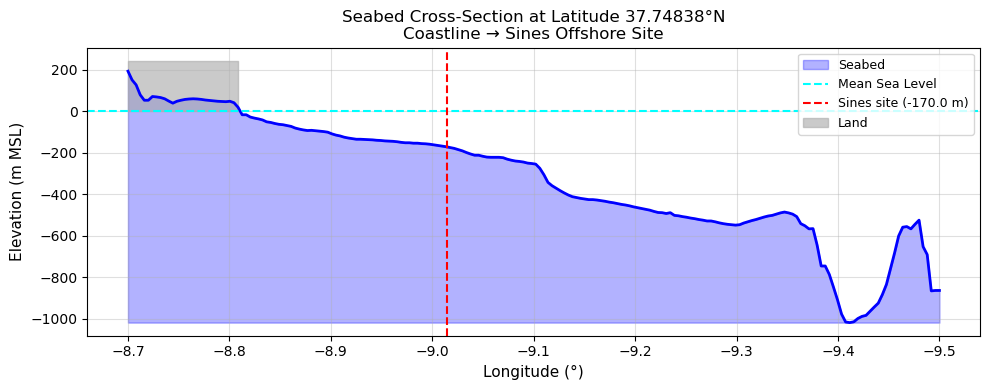

Cross-section saved!


In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Load file ─────────────────────────────────────────────────────
path = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\bathymetry\gebco_2026_n39.5_s36.0_w-11.0_e-7.5.nc'
ds = xr.open_dataset(path)
elev = ds['elevation']
lat  = ds['lat'].values
lon  = ds['lon'].values

# ── 1. Confirm depth at Sines site ───────────────────────────────
site_lat = 37.74838
site_lon = -9.01453

depth_at_site = elev.sel(lat=site_lat, lon=site_lon, method='nearest').values
print(f"GEBCO depth at Sines site: {depth_at_site:.2f} m (negative = below MSL)")

# ── 2. Bathymetric map ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

# Only plot ocean (negative elevation = below sea level)
ocean = elev.where(elev < 0)

# Color map: deep blue → light blue for ocean
im = ax.contourf(lon, lat, ocean,
                 levels=np.linspace(-5000, 0, 100),
                 cmap='Blues_r')

# Land in grey
land = elev.where(elev >= 0)
ax.contourf(lon, lat, land,
            levels=[0, 3000],
            colors=['#a8a8a8'])

# Depth contour lines at key depths
contours = ax.contour(lon, lat, elev,
                      levels=[-3000, -2000, -1000, -500, -200, -168, -100, -50],
                      colors='white', linewidths=0.5, alpha=0.6)
ax.clabel(contours, fmt='%d m', fontsize=7, colors='white')

# Mark your site
ax.plot(site_lon, site_lat, 'r*', markersize=15, label='Sines site (168.55 m)')
ax.annotate('Sines site\n168.55 m MSL',
            xy=(site_lon, site_lat),
            xytext=(site_lon + 0.3, site_lat + 0.2),
            color='red', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'))

# Colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Depth (m MSL)', fontsize=11)

ax.set_xlabel('Longitude (°)', fontsize=11)
ax.set_ylabel('Latitude (°)', fontsize=11)
ax.set_title('Bathymetry of the Sines Offshore Region\nGEBCO 2026 Grid — Mean Sea Level', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-11.0, -7.5)
ax.set_ylim(36.0, 39.5)
ax.grid(True, alpha=0.3, color='white')

plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\bathymetry\bathymetry_map_sines.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Map saved!")

# ── 3. Cross-section: coastline → site ───────────────────────────
# Draw a profile from the coast (lon ~ -8.8) to beyond your site (lon ~ -9.3)
# at constant latitude of your site
profile_lon = np.linspace(-8.7, -9.5, 200)
profile_lat = np.full_like(profile_lon, site_lat)

depths = [float(elev.sel(lat=p_lat, lon=p_lon, method='nearest').values)
          for p_lat, p_lon in zip(profile_lat, profile_lon)]

fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(profile_lon, depths, 'b-', linewidth=2)
ax2.fill_between(profile_lon, depths, min(depths),
                 alpha=0.3, color='blue', label='Seabed')
ax2.axhline(0, color='cyan', linewidth=1.5, linestyle='--', label='Mean Sea Level')
ax2.axvline(site_lon, color='red', linewidth=1.5,
            linestyle='--', label=f'Sines site ({depth_at_site:.1f} m)')
ax2.fill_between(profile_lon, 0, max(depths)+50,
                 where=[d >= 0 for d in depths],
                 color='#a8a8a8', alpha=0.6, label='Land')

ax2.set_xlabel('Longitude (°)', fontsize=11)
ax2.set_ylabel('Elevation (m MSL)', fontsize=11)
ax2.set_title(f'Seabed Cross-Section at Latitude {site_lat}°N\nCoastline → Sines Offshore Site', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)
ax2.invert_xaxis()  # west on the right so it reads shore→offshore left to right

plt.tight_layout()
plt.savefig(r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\bathymetry\cross_section_sines.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Cross-section saved!")